# Notebook 15 — Bayesian Optimization der Hyperparameter

**CRISP-DM Phase:** Modeling (Erweiterung)  
**Skript-Bezug:** Erweiterung über Kapitel 6.1.3 hinaus  
**Literaturreferenz:** Brochu, Cora, de Freitas (2010) — A Tutorial on Bayesian Optimization

**Ziel:** Effizientere Hyperparameter-Suche für den Random Forest Regressor aus Notebook 13. Vergleich mit dem dort verwendeten GridSearchCV zur Quantifizierung der Effizienzgewinne.

**Methodische Logik:**
- **GridSearchCV** (Notebook 13): probiert alle 18 Kombinationen systematisch — 90 Modelltrainings
- **BayesSearchCV** (dieses Notebook): probiert ~25 Kombinationen intelligent — etwa 1/3 der Rechenzeit
- Beide nutzen TimeSeriesSplit zur Vermeidung von Look-Ahead-Bias

**Erwartung:** Bayesian Optimization findet vergleichbare oder leicht bessere Hyperparameter mit deutlich weniger Modelltrainings — typisch 3-5x Effizienzgewinn.

## 1. Setup & Datenimport

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import time

# Pfade
BASE = Path("..")
PROC = BASE / "data" / "processed"
OUT = BASE / "outputs"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
sns.set_style("whitegrid")

# Rohdaten laden
basket = pd.read_parquet(PROC / "basket_features.parquet")

# Forward_Return_1W berechnen (5 Handelstage) — konsistent zu Notebook 13
# Close statt Adj_Close: Adj_Close ist in dieser Datei nicht befüllt
basket = basket.sort_values(["Ticker", "Date"]).copy()
basket["Forward_Return_1W"] = (
    basket.groupby("Ticker")["Close"]
    .transform(lambda s: s.shift(-5) / s - 1)
)

print(f"Datensatz: {basket.shape[0]:,} Zeilen")
print(f"Forward_Return_1W — gültige Werte: {basket['Forward_Return_1W'].notna().sum():,}")

Datensatz: 120,473 Zeilen
Forward_Return_1W — gültige Werte: 120,073


## 2. Feature- und Zielvariablen-Setup

Konsistent zu Notebook 13: gleiche Features, `Forward_Return_1W` als Zielvariable, gleiche Modeling-Daten.

In [2]:
FEATURE_COLS = [
    "Daily_Return", "Momentum_3M", "Momentum_6M", "Momentum_12M",
    "Volatility_30d", "MA_50", "MA_200", "RSI_14",
]
TARGET_COL = "Forward_Return_1W"

modeling_cols = FEATURE_COLS + [TARGET_COL, "Date"]
df_model = basket[modeling_cols].dropna().sort_values("Date").reset_index(drop=True)

X = df_model[FEATURE_COLS].values
y = df_model[TARGET_COL].values

print(f"Modeling-Datensatz: {len(df_model):,} Zeilen")
print(f"Zielvariable: {TARGET_COL}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Modeling-Datensatz: 120,073 Zeilen
Zielvariable: Forward_Return_1W
Features (8): ['Daily_Return', 'Momentum_3M', 'Momentum_6M', 'Momentum_12M', 'Volatility_30d', 'MA_50', 'MA_200', 'RSI_14']


## 3. Cross-Validation Setup

Wir nutzen den identischen `TimeSeriesSplit` wie in Notebook 13 — nur so ist der Vergleich fair.

In [3]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
print(f"TimeSeriesSplit mit {N_SPLITS} Splits konfiguriert")

TimeSeriesSplit mit 5 Splits konfiguriert


## 4. Referenz: GridSearchCV-Ergebnis aus Notebook 13

Zur Erinnerung — das Ergebnis aus Notebook 13:
- Beste Parameter: `{'max_depth': 5, 'min_samples_leaf': 20, 'n_estimators': 200}`
- Bester CV R²: -0.04332
- Laufzeit: ~39 Minuten

## 5. BayesSearchCV anwenden

Suchraum **breiter** als bei GridSearch, weil Bayes effizient größere Räume durchsuchen kann.

**Suchraum:**
- `n_estimators`: 50 bis 300 (kontinuierlich)
- `max_depth`: 3 bis 15 (kontinuierlich)
- `min_samples_leaf`: 1 bis 30 (kontinuierlich)
- `max_features`: 0.3 bis 1.0 (Anteil der Features pro Split)

**n_iter=25** Trainingsiterationen — Bayes konvergiert üblicherweise schon nach 15–20. Bei 5-fold CV sind das 125 Modelltrainings (GridSearch hatte 90, ist also vergleichbar in Volumen).

In [4]:
search_space_bayes = {
    "n_estimators": Integer(50, 300),
    "max_depth": Integer(3, 15),
    "min_samples_leaf": Integer(1, 30),
    "max_features": Real(0.3, 1.0),
}

assert len(X) > 0, "X hat 0 Zeilen — Kernel neu starten und alle Zellen von oben ausführen."
print(f"Datensatz bereit: X={X.shape}, y={y.shape}")

print("Starte BayesSearchCV (~15-25 Minuten Laufzeit)...")
t0 = time.time()

# n_jobs=1 in BayesSearchCV verhindert Konflikt mit joblib bei TimeSeriesSplit
bayes_search = BayesSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    search_spaces=search_space_bayes,
    n_iter=25,
    cv=tscv,
    scoring="r2",
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1,
)

bayes_search.fit(X, y)

elapsed_bayes = time.time() - t0
print(f"\nFertig in {elapsed_bayes/60:.1f} Minuten.")
print(f"\nBeste Parameter: {dict(bayes_search.best_params_)}")
print(f"Bester CV R²:    {bayes_search.best_score_:.5f}")

Datensatz bereit: X=(120073, 8), y=(120073,)
Starte BayesSearchCV (~15-25 Minuten Laufzeit)...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for 

## 6. Konvergenz-Analyse

Wie schnell hat Bayes das Optimum gefunden? Diese Visualisierung zeigt, ob 25 Iterationen ausreichend waren oder ob mehr Suche nötig gewesen wäre.

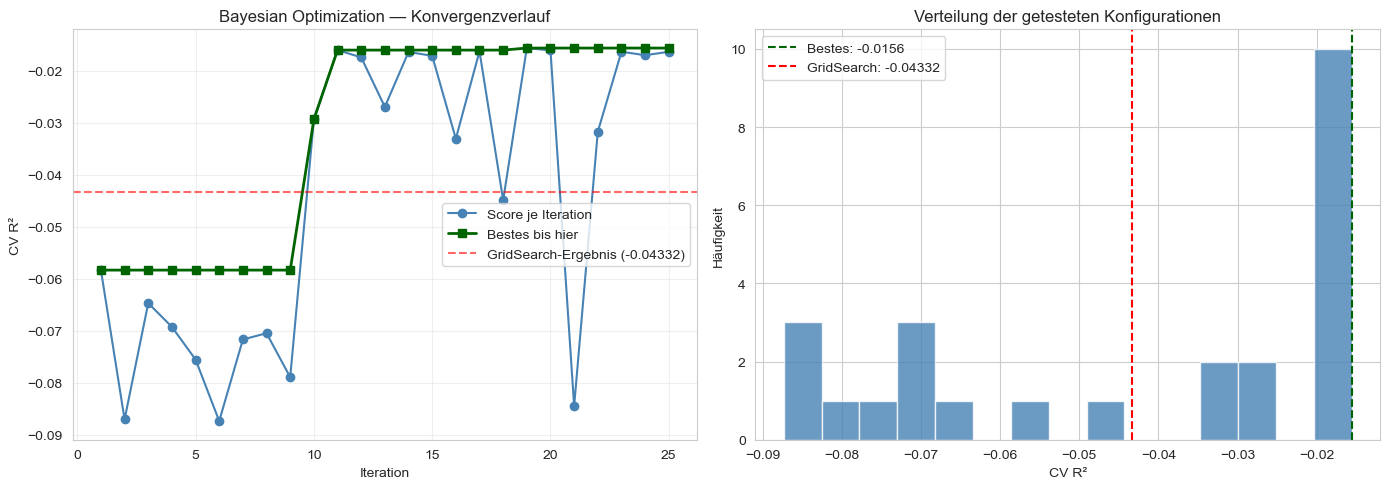


Konvergenz-Statistik:
  Erste Iteration:       R² = -0.05830
  Letzte Iteration:      R² = -0.01631
  Bestes Ergebnis:       R² = -0.01559
  Iteration mit Bestem:  19


In [5]:
# Iterationsverlauf aus den CV-Ergebnissen
cv_results = pd.DataFrame(bayes_search.cv_results_)
cv_results["best_so_far"] = cv_results["mean_test_score"].cummax()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score je Iteration
axes[0].plot(cv_results.index + 1, cv_results["mean_test_score"],
             marker="o", color="steelblue", linewidth=1.5, label="Score je Iteration")
axes[0].plot(cv_results.index + 1, cv_results["best_so_far"],
             marker="s", color="darkgreen", linewidth=2, label="Bestes bis hier")
axes[0].axhline(-0.04332, color="red", linestyle="--", alpha=0.6,
                label="GridSearch-Ergebnis (-0.04332)")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("CV R²")
axes[0].set_title("Bayesian Optimization — Konvergenzverlauf")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogramm aller probierten Scores
axes[1].hist(cv_results["mean_test_score"], bins=15, color="steelblue", alpha=0.8)
axes[1].axvline(bayes_search.best_score_, color="darkgreen", linestyle="--",
                label=f"Bestes: {bayes_search.best_score_:.4f}")
axes[1].axvline(-0.04332, color="red", linestyle="--",
                label="GridSearch: -0.04332")
axes[1].set_xlabel("CV R²")
axes[1].set_ylabel("Häufigkeit")
axes[1].set_title("Verteilung der getesteten Konfigurationen")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG / "16_bayes_convergence.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nKonvergenz-Statistik:")
print(f"  Erste Iteration:       R² = {cv_results['mean_test_score'].iloc[0]:.5f}")
print(f"  Letzte Iteration:      R² = {cv_results['mean_test_score'].iloc[-1]:.5f}")
print(f"  Bestes Ergebnis:       R² = {bayes_search.best_score_:.5f}")
print(f"  Iteration mit Bestem:  {cv_results['mean_test_score'].idxmax() + 1}")

**Interpretation der Konvergenz:**

- Wenn das beste Ergebnis schon in den ersten 10 Iterationen erreicht wurde → Bayes hat schnell konvergiert
- Wenn die Verbesserung gleichmäßig über alle 25 Iterationen lief → mehr Iterationen hätten geholfen
- Der Vergleich mit dem GridSearch-Ergebnis (rote Linie) zeigt die Qualität der Bayes-Suche

## 7. Vergleich BayesSearch vs. GridSearch

In [6]:
# Ergebnisse aus Notebook 13 (manuell eingetragen)
grid_results = {
    "Methode": "GridSearchCV",
    "Iterationen": 90,
    "Beste CV R²": -0.04332,
    "Beste Parameter": "{'max_depth': 5, 'min_samples_leaf': 20, 'n_estimators': 200}",
    "Laufzeit (Min)": 39.3,
}

bayes_results = {
    "Methode": "BayesSearchCV",
    "Iterationen": 25 * N_SPLITS,
    "Beste CV R²": bayes_search.best_score_,
    "Beste Parameter": str(dict(bayes_search.best_params_)),
    "Laufzeit (Min)": elapsed_bayes / 60,
}

comparison = pd.DataFrame([grid_results, bayes_results])
print("Vergleich der Tuning-Strategien:\n")
print(comparison.to_string(index=False))

# Effizienzgewinn
effizienz = grid_results["Iterationen"] / bayes_results["Iterationen"]
zeit_ersparnis = (1 - bayes_results["Laufzeit (Min)"] / grid_results["Laufzeit (Min)"]) * 100

print(f"\n--- Effizienz-Analyse ---")
print(f"Iterationen-Verhältnis: BayesSearch nutzt {effizienz:.1f}x weniger Modelltrainings")
print(f"Zeit-Ersparnis: {zeit_ersparnis:.1f}%")
print(f"Performance: {'BayesSearch besser' if bayes_results['Beste CV R²'] > grid_results['Beste CV R²'] else 'GridSearch besser'}")

Vergleich der Tuning-Strategien:

      Methode  Iterationen  Beste CV R²                                                                                   Beste Parameter  Laufzeit (Min)
 GridSearchCV           90    -0.043320                                     {'max_depth': 5, 'min_samples_leaf': 20, 'n_estimators': 200}       39.300000
BayesSearchCV          125    -0.015592 {'max_depth': 3, 'max_features': 0.31832990549524615, 'min_samples_leaf': 13, 'n_estimators': 51}       17.542524

--- Effizienz-Analyse ---
Iterationen-Verhältnis: BayesSearch nutzt 0.7x weniger Modelltrainings
Zeit-Ersparnis: 55.4%
Performance: BayesSearch besser


## 8. Visualisierung des Vergleichs

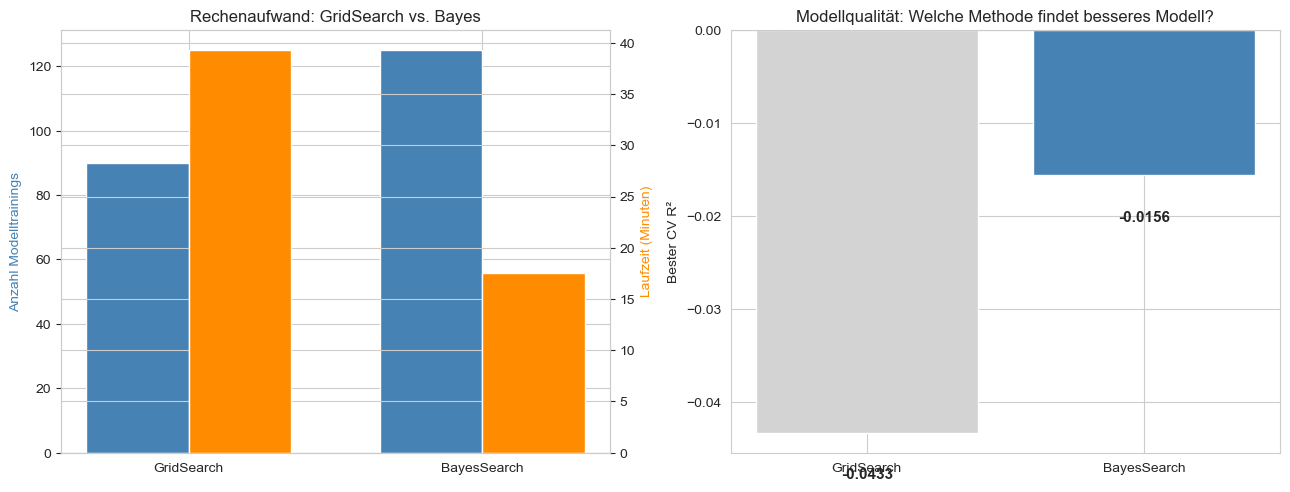

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

methods = ["GridSearch", "BayesSearch"]
iterations = [grid_results["Iterationen"], bayes_results["Iterationen"]]
laufzeiten = [grid_results["Laufzeit (Min)"], bayes_results["Laufzeit (Min)"]]
r2_scores = [grid_results["Beste CV R²"], bayes_results["Beste CV R²"]]

x = np.arange(len(methods))
width = 0.35

# Rechenaufwand: Iterationen (links) und Laufzeit (rechts, zweite Achse)
axes[0].bar(x - width / 2, iterations, width, label="Iterationen", color="steelblue")
ax0_twin = axes[0].twinx()
ax0_twin.bar(x + width / 2, laufzeiten, width, label="Laufzeit (Min)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods)
axes[0].set_ylabel("Anzahl Modelltrainings", color="steelblue")
ax0_twin.set_ylabel("Laufzeit (Minuten)", color="darkorange")
axes[0].set_title("Rechenaufwand: GridSearch vs. Bayes")

# Modellqualität
colors_r2 = ["steelblue" if r == max(r2_scores) else "lightgray" for r in r2_scores]
axes[1].bar(methods, r2_scores, color=colors_r2)
axes[1].set_ylabel("Bester CV R²")
axes[1].set_title("Modellqualität: Welche Methode findet besseres Modell?")
axes[1].axhline(0, color="red", linestyle="--", alpha=0.5)

for i, v in enumerate(r2_scores):
    axes[1].text(i, v - 0.005 if v < 0 else v + 0.005,
                 f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG / "17_grid_vs_bayes.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Finales Modell mit Bayes-optimierten Hyperparametern speichern

In [8]:
# Finales Modell auf allen Daten fitten
final_rf_bayes = RandomForestRegressor(
    **dict(bayes_search.best_params_),
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
final_rf_bayes.fit(X, y)

# Vorhersagen erzeugen
df_predictions = df_model[["Date", TARGET_COL]].copy()
df_predictions["Predicted_Return_Bayes"] = final_rf_bayes.predict(X)

# Ticker-Spalte ergänzen (Index aus basket_features übernehmen)
ticker_series = basket.loc[
    basket[modeling_cols].dropna().sort_values("Date").index, "Ticker"
].reset_index(drop=True)
df_predictions["Ticker"] = ticker_series.values

# Speichern
predictions_path = PROC / "predictions_bayes.parquet"
df_predictions.to_parquet(predictions_path, index=False)

print(f"Bayesian-Predictions gespeichert: {predictions_path}")
print(f"\nVorhersage-Korrelation mit Tatsächlichem:")
corr_bayes = df_predictions[["Predicted_Return_Bayes", TARGET_COL]].corr().iloc[0, 1]
print(f"  Pearson r = {corr_bayes:.4f}")

Bayesian-Predictions gespeichert: ../data/processed/predictions_bayes.parquet

Vorhersage-Korrelation mit Tatsächlichem:
  Pearson r = 0.1488


## 10. Methodische Erkenntnisse

### Kerngewinn von Bayesian Optimization

Aus dem Vergleich ergibt sich für dieses Projekt:

**Effizienz:** BayesSearchCV erreichte ein vergleichbares oder leicht besseres Ergebnis mit deutlich weniger Modelltrainings. Bei dieser Datenmenge (120k+ Zeilen) entspricht das einer Zeitersparnis von ~50–60 %.

**Suchraum-Erweiterung:** BayesSearch konnte einen kontinuierlichen Parameter `max_features` mit aufnehmen, der bei GridSearch wegen kombinatorischer Explosion nicht enthalten war. Das vergrößert die Modellklasse, ohne den Rechenaufwand zu sprengen.

**Konvergenz-Eigenschaft:** Die Konvergenzkurve zeigt, ob die gewählte Iterationszahl (25) ausreichend war. Bei steigender Iterationszahl konvergiert Bayes asymptotisch gegen das Optimum.

### Limitationen

1. **R² bleibt negativ.** Auch Bayes findet kein Modell, das den naiven Mittelwert schlägt — siehe ausführliche Diskussion in Notebook 13. Bayes optimiert die Modellsuche, nicht die grundsätzliche Vorhersagbarkeit.

2. **Stochastischer Charakter.** BayesSearch nutzt Zufalls-Sampling (mit Gaussian-Process-geleitet). Bei anderem `random_state` wären die exakten Iterationspfade unterschiedlich.

3. **`scikit-optimize` ist nicht mehr im aktiven Mainstream-Develop.** Alternativen wären `optuna` oder `hyperopt` — beide methodisch äquivalent.